In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
data=pd.read_csv('/kaggle/input/datasets/manishavelamani/electricity-forecasting/PJME_preprocessd.csv',parse_dates=['Datetime'],index_col='Datetime')

In [5]:
data.head()

,PJME_MW,PJME_MW_Scaled,Hour,Day,Week,Month,DayOfWeek,Weekend,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingStd_24,RollingMean_168
Datetime,,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,0.433011,1,8,2,1,1,0,31187.0,26862.0,27100.0,30393.0,33560.208333,4425.965952,32513.869048
2002-01-08 02:00:00,28670.0,0.409021,2,8,2,1,1,0,29445.0,25976.0,26097.0,29265.0,33672.458333,4256.159403,32510.327381
2002-01-08 03:00:00,28375.0,0.399889,3,8,2,1,1,0,28670.0,25641.0,25793.0,28357.0,33786.375000,4064.104959,32510.434524
2002-01-08 04:00:00,28542.0,0.405058,4,8,2,1,1,0,28375.0,25666.0,25657.0,27899.0,33906.208333,3851.076461,32514.261905
2002-01-08 05:00:00,29261.0,0.427316,5,8,2,1,1,0,28542.0,26328.0,25778.0,28057.0,34028.416667,3640.941409,32521.428571


In [6]:
series=data['PJME_MW_Scaled']
series.head()

Datetime
2002-01-08 01:00:00    0.433011
2002-01-08 02:00:00    0.409021
2002-01-08 03:00:00    0.399889
2002-01-08 04:00:00    0.405058
2002-01-08 05:00:00    0.427316
Name: PJME_MW_Scaled, dtype: float64

In [7]:
train_size=int(len(series)*0.70)
val_size=int(len(series)*0.10)
train = series.iloc[:train_size]
validation = series.iloc[train_size:train_size + val_size]
test = series.iloc[train_size + val_size:]
print('Train:', len(train))
print('Validation:', len(validation))
print('Test:', len(test))

Train: 101656
Validation: 14522
Test: 29046


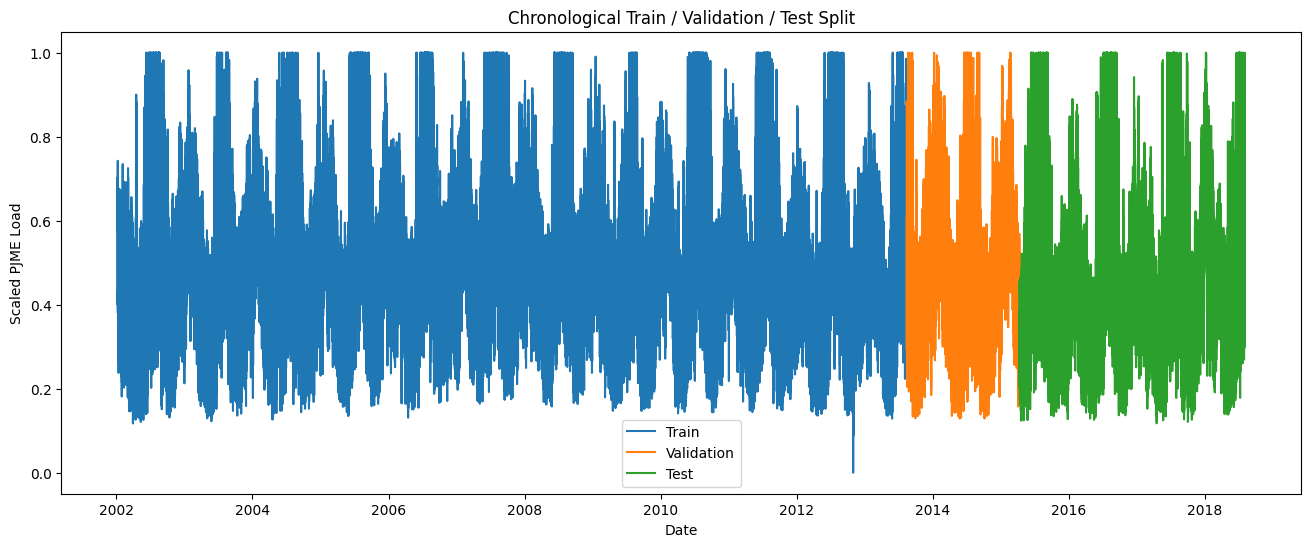

In [8]:
plt.figure(figsize=(16,6))
plt.plot(train.index, train, label='Train')
plt.plot(validation.index, validation, label='Validation')
plt.plot(test.index, test, label='Test')
plt.title('Chronological Train / Validation / Test Split')
plt.xlabel('Date')
plt.ylabel('Scaled PJME Load')
plt.legend()
plt.show()

In [16]:
def create_sequences(series, sequence_length, forecast_horizon=24):
    X = []
    y = []

    values = series.values

    for i in range(len(values) - sequence_length - forecast_horizon + 1):
        X.append(values[i:i + sequence_length])
        y.append(values[i + sequence_length:i + sequence_length + forecast_horizon])

    return np.array(X), np.array(y)

# sequential length=24

In [17]:
sequence_length = 24

X_train,y_train = create_sequences(train,sequence_length)
X_val,y_val = create_sequences(validation,sequence_length)
X_test,y_test = create_sequences(test,sequence_length)
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(101609, 24)
(101609, 24)
(14475, 24)
(14475, 24)
(28999, 24)
(28999, 24)


In [18]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(101609, 24, 1)
(14475, 24, 1)
(28999, 24, 1)


# Basic RNN

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense
rnn_model=Sequential([
    SimpleRNN(32,input_shape=(sequence_length,1)),
    Dense(24)])
rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.summary()    

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,880 (7.34 KB)

 Trainable params: 1,880 (7.34 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
basic_rnn_history=rnn_model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 0.0102 - val_loss: 0.0069
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0056 - val_loss: 0.0057
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0053 - val_loss: 0.0055
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0051 - val_loss: 0.0054
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0050 - val_loss: 0.0057
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0048 - val_loss: 0.0054
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0047 - val_loss: 0.0055
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0047 - val_loss: 0.0053
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0046 - val_loss: 0.0054
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0046 - val_loss: 0.0050


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(data[['PJME_MW']])

MinMaxScaler()

# LSTM

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(32, input_shape=(sequence_length, 1)),
    Dense(24)
])

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,144 (20.09 KB)

 Trainable params: 5,144 (20.09 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
lstm_history=lstm_model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 0.0113 - val_loss: 0.0072
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 0.0057 - val_loss: 0.0058
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 0.0051 - val_loss: 0.0055
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 0.0048 - val_loss: 0.0055
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 0.0046 - val_loss: 0.0050
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 0.0045 - val_loss: 0.0050
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 0.0044 - val_loss: 0.0048
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 0.0043 - val_loss: 0.0048
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 0.0042 - val_loss: 0.0047
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 0.0041 - val_loss: 0.0048


# GRU

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

gru_model = Sequential([
    GRU(32, input_shape=(sequence_length, 1)),
    Dense(24)
])

gru_model.compile(optimizer='adam', loss='mse')

gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,152 (16.22 KB)

 Trainable params: 4,152 (16.22 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
gru_history=gru_model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 0.0120 - val_loss: 0.0070
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 0.0057 - val_loss: 0.0057
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 0.0051 - val_loss: 0.0058
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 0.0048 - val_loss: 0.0053
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 0.0046 - val_loss: 0.0054
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 0.0045 - val_loss: 0.0053
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 0.0044 - val_loss: 0.0050
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 0.0043 - val_loss: 0.0054
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 0.0042 - val_loss: 0.0051
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 0.0041 - val_loss: 0.0050


# Bidirectional LSTM

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense

bilstm_model = Sequential([
    Bidirectional(LSTM(32), input_shape=(sequence_length, 1)),
    Dense(24)
])

bilstm_model.compile(optimizer='adam', loss='mse')

bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,264 (40.09 KB)

 Trainable params: 10,264 (40.09 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
bilstm_history=bilstm_model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 0.0098 - val_loss: 0.0062
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 0.0054 - val_loss: 0.0056
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 0.0049 - val_loss: 0.0054
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 0.0046 - val_loss: 0.0049
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 0.0044 - val_loss: 0.0050
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 0.0042 - val_loss: 0.0055
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 0.0041 - val_loss: 0.0047
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 0.0039 - val_loss: 0.0048
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 0.0039 - val_loss: 0.0047
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 0.0038 - val_loss: 0.0046


# EvalauateMetrics for All model using this function

In [32]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,r2_score)
import numpy as np
def evaluate_model(model, X_test, y_test, scaler, sequence_length, model_name):
    predictions = model.predict(X_test, verbose=0)
    pred_original = scaler.inverse_transform( predictions.reshape(-1, 1)).reshape(predictions.shape)
    y_original = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
    mae = mean_absolute_error(y_original.flatten(),pred_original.flatten())
    mse = mean_squared_error( y_original.flatten(),pred_original.flatten())
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_original.flatten(),pred_original.flatten()) * 100
    r2 = r2_score(y_original.flatten(),pred_original.flatten())
    bias = np.mean(pred_original.flatten() - y_original.flatten())
    return {
        'Sequence Length': sequence_length,
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2,
        'Bias': bias
    }

# evaluate for sequential length is 24

In [33]:
results_24 = []

results_24.append(evaluate_model(rnn_model, X_test, y_test, scaler, 24, 'Basic RNN'))
results_24.append(evaluate_model(lstm_model, X_test, y_test, scaler, 24, 'LSTM'))
results_24.append(evaluate_model(gru_model, X_test, y_test, scaler, 24, 'GRU'))
results_24.append(evaluate_model(bilstm_model, X_test, y_test, scaler, 24, 'Bidirectional LSTM'))
results_24 = pd.DataFrame(results_24)
results_24

,Sequence Length,Model,MAE,MSE,RMSE,MAPE,R2,Bias
0,24,Basic RNN,1673.267978,5.235666e+06,2288.157782,5.511059,0.868718,479.548749
1,24,LSTM,1708.357948,5.422142e+06,2328.549302,5.682975,0.864042,663.334699
2,24,GRU,1669.474113,5.289771e+06,2299.950245,5.481745,0.867361,583.574416
3,24,Bidirectional LSTM,1600.374889,5.062039e+06,2249.897472,5.212504,0.873071,265.969500


# Sequential length=48

In [34]:
sequence_length =48

X_train,y_train = create_sequences(train,sequence_length)
X_val,y_val = create_sequences(validation,sequence_length)
X_test,y_test = create_sequences(test,sequence_length)
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(101585, 48)
(101585, 24)
(14451, 48)
(14451, 24)
(28975, 48)
(28975, 24)


In [35]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(101585, 48, 1)
(14451, 48, 1)
(28975, 48, 1)


# Basic RNN

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense
rnn_model_48=Sequential([
    SimpleRNN(32,input_shape=(sequence_length,1)),
    Dense(24)])
rnn_model_48.compile(optimizer='adam',loss='mse')
rnn_model_48.summary()    

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,880 (7.34 KB)

 Trainable params: 1,880 (7.34 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
basic_rnn48_history=rnn_model_48.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 0.0103 - val_loss: 0.0057
Epoch 2/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 0.0053 - val_loss: 0.0057
Epoch 3/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 0.0050 - val_loss: 0.0053
Epoch 4/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 0.0048 - val_loss: 0.0051
Epoch 5/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 0.0046 - val_loss: 0.0050
Epoch 6/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 0.0044 - val_loss: 0.0048
Epoch 7/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 0.0043 - val_loss: 0.0051
Epoch 8/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 0.0042 - val_loss: 0.0047
Epoch 9/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 0.0041 - val_loss: 0.0046
Epoch 10/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 0.0041 - val_loss: 0.0049


# LSTM

In [38]:
from tensorflow.keras.layers import LSTM,Dense
lstm_model_48 = Sequential([
    LSTM(32, input_shape=(sequence_length,1)),
    Dense(24)
])
lstm_model_48.compile(optimizer='adam',loss='mse')
lstm_model_48.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,144 (20.09 KB)

 Trainable params: 5,144 (20.09 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
lstm_48_history=lstm_model_48.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 0.0120 - val_loss: 0.0067
Epoch 2/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 0.0053 - val_loss: 0.0052
Epoch 3/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 0.0047 - val_loss: 0.0051
Epoch 4/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 0.0044 - val_loss: 0.0055
Epoch 5/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 0.0042 - val_loss: 0.0049
Epoch 6/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 0.0040 - val_loss: 0.0046
Epoch 7/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 0.0038 - val_loss: 0.0046
Epoch 8/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 0.0037 - val_loss: 0.0044
Epoch 9/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 0.0036 - val_loss: 0.0041
Epoch 10/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 0.0035 - val_loss: 0.0044


# GRU

In [40]:
from tensorflow.keras.layers import GRU,Dense
gru_model_48= Sequential([
    GRU(32,input_shape=(sequence_length,1)),
    Dense(24)
])
gru_model_48.compile(optimizer='adam',loss='mse')
gru_model_48.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,152 (16.22 KB)

 Trainable params: 4,152 (16.22 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
gru_48_history=gru_model_48.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 57s 17ms/step - loss: 0.0113 - val_loss: 0.0062
Epoch 2/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 55s 17ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 3/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 0.0047 - val_loss: 0.0051
Epoch 4/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 0.0045 - val_loss: 0.0051
Epoch 5/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 0.0043 - val_loss: 0.0053
Epoch 6/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 0.0042 - val_loss: 0.0053
Epoch 7/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 0.0041 - val_loss: 0.0047
Epoch 8/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 0.0040 - val_loss: 0.0044
Epoch 9/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 0.0039 - val_loss: 0.0043
Epoch 10/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - loss: 0.0037 - val_loss: 0.0043


# Bidirectional LSTM

In [42]:
from tensorflow.keras.layers import LSTM,Dense,Bidirectional
bilstm_model_48= Sequential([
    Bidirectional(LSTM(32), input_shape=(sequence_length,1)),
    Dense(24)
])
bilstm_model_48.compile(optimizer='adam',loss='mse')
bilstm_model_48.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 64)             │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,264 (40.09 KB)

 Trainable params: 10,264 (40.09 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
bilstm_48_history=bilstm_model_48.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - loss: 0.0096 - val_loss: 0.0070
Epoch 2/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 51s 16ms/step - loss: 0.0054 - val_loss: 0.0057
Epoch 3/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 51s 16ms/step - loss: 0.0047 - val_loss: 0.0053
Epoch 4/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - loss: 0.0044 - val_loss: 0.0052
Epoch 5/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - loss: 0.0041 - val_loss: 0.0049
Epoch 6/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 51s 16ms/step - loss: 0.0039 - val_loss: 0.0045
Epoch 7/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - loss: 0.0037 - val_loss: 0.0043
Epoch 8/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - loss: 0.0036 - val_loss: 0.0045
Epoch 9/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - loss: 0.0035 - val_loss: 0.0042
Epoch 10/10
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - loss: 0.0034 - val_loss: 0.0041


# Evaluate Metrics for sequential length is 48

In [44]:
results_48 = []

results_48.append(evaluate_model(rnn_model_48, X_test, y_test, scaler, 48, 'Basic RNN'))
results_48.append(evaluate_model(lstm_model_48, X_test, y_test, scaler, 48, 'LSTM'))
results_48.append(evaluate_model(gru_model_48, X_test, y_test, scaler, 48, 'GRU'))
results_48.append(evaluate_model(bilstm_model_48, X_test, y_test, scaler, 48, 'Bidirectional LSTM'))
results_48 = pd.DataFrame(results_48)
results_48

,Sequence Length,Model,MAE,MSE,RMSE,MAPE,R2,Bias
0,48,Basic RNN,1730.538650,5.435022e+06,2331.313280,5.733010,0.863707,716.356854
1,48,LSTM,1636.370860,5.101147e+06,2258.571787,5.415891,0.872080,657.866184
2,48,GRU,1590.640898,4.849759e+06,2202.216813,5.222647,0.878384,447.157368
3,48,Bidirectional LSTM,1538.890909,4.622597e+06,2150.022597,5.021082,0.884080,516.241265


# Sequential length=168

In [45]:
sequence_length =168

X_train,y_train = create_sequences(train,sequence_length)
X_val,y_val = create_sequences(validation,sequence_length)
X_test,y_test = create_sequences(test,sequence_length)
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(101465, 168)
(101465, 24)
(14331, 168)
(14331, 24)
(28855, 168)
(28855, 24)


In [46]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(101465, 168, 1)
(14331, 168, 1)
(28855, 168, 1)


# Bsic RNN

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense
rnn_model_168=Sequential([
    SimpleRNN(32,input_shape=(sequence_length,1)),
    Dense(24)])
rnn_model_168.compile(optimizer='adam',loss='mse')
rnn_model_168.summary()    

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,880 (7.34 KB)

 Trainable params: 1,880 (7.34 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
basic_rnn168_history=rnn_model_168.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 69s 21ms/step - loss: 0.0098 - val_loss: 0.0056
Epoch 2/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 67s 21ms/step - loss: 0.0053 - val_loss: 0.0054
Epoch 3/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 67s 21ms/step - loss: 0.0050 - val_loss: 0.0053
Epoch 4/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 67s 21ms/step - loss: 0.0048 - val_loss: 0.0051
Epoch 5/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 67s 21ms/step - loss: 0.0046 - val_loss: 0.0050
Epoch 6/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 67s 21ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 7/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 67s 21ms/step - loss: 0.0040 - val_loss: 0.0045
Epoch 8/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 68s 21ms/step - loss: 0.0039 - val_loss: 0.0045
Epoch 9/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 67s 21ms/step - loss: 0.0038 - val_loss: 0.0044
Epoch 10/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 68s 21ms/step - loss: 0.0037 - val_loss: 0.0042


# LSTM

In [49]:
from tensorflow.keras.layers import LSTM,Dense
lstm_model_168 = Sequential([
    LSTM(32, input_shape=(sequence_length,1)),
    Dense(24)
])
lstm_model_168.compile(optimizer='adam',loss='mse')
lstm_model_168.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,144 (20.09 KB)

 Trainable params: 5,144 (20.09 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
lstm_168_history=lstm_model_168.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 165s 51ms/step - loss: 0.0113 - val_loss: 0.0063
Epoch 2/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 162s 51ms/step - loss: 0.0052 - val_loss: 0.0052
Epoch 3/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 162s 51ms/step - loss: 0.0045 - val_loss: 0.0049
Epoch 4/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 162s 51ms/step - loss: 0.0040 - val_loss: 0.0050
Epoch 5/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 163s 51ms/step - loss: 0.0037 - val_loss: 0.0045
Epoch 6/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 163s 52ms/step - loss: 0.0035 - val_loss: 0.0041
Epoch 7/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 163s 51ms/step - loss: 0.0034 - val_loss: 0.0041
Epoch 8/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 163s 51ms/step - loss: 0.0033 - val_loss: 0.0040
Epoch 9/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 163s 51ms/step - loss: 0.0032 - val_loss: 0.0039
Epoch 10/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 164s 52ms/step - loss: 0.0030 - val_loss: 0.0037


# GRU

In [51]:
from tensorflow.keras.layers import GRU,Dense
gru_model_168= Sequential([
    GRU(32,input_shape=(sequence_length,1)),
    Dense(24)
])
gru_model_168.compile(optimizer='adam',loss='mse')
gru_model_168.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,152 (16.22 KB)

 Trainable params: 4,152 (16.22 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
gru_168_history=gru_model_168.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 205s 64ms/step - loss: 0.0113 - val_loss: 0.0060
Epoch 2/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 202s 64ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 3/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 201s 63ms/step - loss: 0.0042 - val_loss: 0.0046
Epoch 4/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 199s 63ms/step - loss: 0.0039 - val_loss: 0.0045
Epoch 5/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 205s 65ms/step - loss: 0.0037 - val_loss: 0.0040
Epoch 6/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 201s 63ms/step - loss: 0.0036 - val_loss: 0.0040
Epoch 7/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 201s 63ms/step - loss: 0.0035 - val_loss: 0.0040
Epoch 8/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 201s 63ms/step - loss: 0.0034 - val_loss: 0.0039
Epoch 9/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 203s 64ms/step - loss: 0.0033 - val_loss: 0.0038
Epoch 10/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 201s 63ms/step - loss: 0.0032 - val_loss: 0.0036


# Bidirectional LSTM

In [56]:
from tensorflow.keras.layers import LSTM,Dense,Bidirectional
bilstm_model_168= Sequential([
    Bidirectional(LSTM(32), input_shape=(sequence_length,1)),
    Dense(24)
])
bilstm_model_168.compile(optimizer='adam',loss='mse')
bilstm_model_168.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 64)             │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,264 (40.09 KB)

 Trainable params: 10,264 (40.09 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
bilstm_168_history=bilstm_model_168.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 161s 50ms/step - loss: 0.0081 - val_loss: 0.0053
Epoch 2/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 158s 50ms/step - loss: 0.0042 - val_loss: 0.0047
Epoch 3/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 159s 50ms/step - loss: 0.0036 - val_loss: 0.0041
Epoch 4/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 159s 50ms/step - loss: 0.0033 - val_loss: 0.0039
Epoch 5/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 160s 50ms/step - loss: 0.0032 - val_loss: 0.0040
Epoch 6/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 159s 50ms/step - loss: 0.0031 - val_loss: 0.0037
Epoch 7/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 161s 51ms/step - loss: 0.0030 - val_loss: 0.0036
Epoch 8/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 159s 50ms/step - loss: 0.0029 - val_loss: 0.0035
Epoch 9/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 159s 50ms/step - loss: 0.0028 - val_loss: 0.0034
Epoch 10/10
3171/3171 ━━━━━━━━━━━━━━━━━━━━ 158s 50ms/step - loss: 0.0028 - val_loss: 0.0034


In [58]:
results_168 = []
results_168.append(evaluate_model(rnn_model_168, X_test, y_test, scaler, 168, 'Basic RNN'))
results_168.append(evaluate_model(lstm_model_168, X_test, y_test, scaler, 168, 'LSTM'))
results_168.append(evaluate_model(gru_model_168, X_test, y_test, scaler, 168, 'GRU'))
results_168.append(evaluate_model(bilstm_model_168, X_test, y_test, scaler, 168, 'Bidirectional LSTM'))
results_168 = pd.DataFrame(results_168)
results_168

,Sequence Length,Model,MAE,MSE,RMSE,MAPE,R2,Bias
0,168,Basic RNN,1525.766367,4.405980e+06,2099.042521,4.969714,0.889640,315.708250
1,168,LSTM,1469.947544,4.021210e+06,2005.295450,4.737814,0.899278,293.431907
2,168,GRU,1430.083717,3.936318e+06,1984.015685,4.567817,0.901404,-6.780432
3,168,Bidirectional LSTM,1375.059203,3.694165e+06,1922.021009,4.399766,0.907469,197.749659


In [59]:
comparison_phase5 = pd.concat([results_24, results_48, results_168],ignore_index=True)
comparison_phase5 = comparison_phase5.sort_values('RMSE').reset_index(drop=True)
comparison_phase5

,Sequence Length,Model,MAE,MSE,RMSE,MAPE,R2,Bias
0,168,Bidirectional LSTM,1375.059203,3.694165e+06,1922.021009,4.399766,0.907469,197.749659
1,168,GRU,1430.083717,3.936318e+06,1984.015685,4.567817,0.901404,-6.780432
2,168,LSTM,1469.947544,4.021210e+06,2005.295450,4.737814,0.899278,293.431907
3,168,Basic RNN,1525.766367,4.405980e+06,2099.042521,4.969714,0.889640,315.708250
4,48,Bidirectional LSTM,1538.890909,4.622597e+06,2150.022597,5.021082,0.884080,516.241265
5,48,GRU,1590.640898,4.849759e+06,2202.216813,5.222647,0.878384,447.157368
6,24,Bidirectional LSTM,1600.374889,5.062039e+06,2249.897472,5.212504,0.873071,265.969500
7,48,LSTM,1636.370860,5.101147e+06,2258.571787,5.415891,0.872080,657.866184
8,24,Basic RNN,1673.267978,5.235666e+06,2288.157782,5.511059,0.868718,479.548749
9,24,GRU,1669.474113,5.289771e+06,2299.950245,5.481745,0.867361,583.574416


In [62]:
comparison_phase5.to_csv('/kaggle/working/comparison_phase5.csv')